### **5.1 ΠΡΟΒΛΕΨΗ ΚΑΤΑΝΑΛΩΣΗΣ ΗΜΕΡΑΣ ΣΕ ΧΑΜΗΛΗ Ή ΥΨΥΛΗ**

In [1]:
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pandas as pd

df = pd.read_pickle('/content/drive/MyDrive/Data_Mining/Projects/df_final.pkl')

In [4]:
df['Consumption'].unique()

array([1., 0.])

In [5]:
from sklearn.model_selection import train_test_split

In [6]:
X = df.drop(columns=['Consumption','Daily_total_power'], axis=1)
Y = df['Consumption']
X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size=0.3)

In [7]:
Y

,Consumption
Datetime,
2006-12-31,1.0
2007-01-01,1.0
2007-01-02,0.0
2007-01-03,0.0
2007-01-04,1.0
...,...
2010-11-20,1.0
2010-11-21,0.0
2010-11-22,1.0


In [8]:
from sklearn.tree import DecisionTreeClassifier

In [9]:
dtree = DecisionTreeClassifier(criterion='entropy')

In [10]:
dtree.fit(X_train,Y_train)

DecisionTreeClassifier(criterion='entropy')

In [11]:
predictions = dtree.predict(X_test)

In [12]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score

In [13]:
print(confusion_matrix(Y_test,predictions))
print(classification_report(Y_test,predictions))
print(accuracy_score(Y_test,predictions))

y_probs = dtree.predict_proba(X_test)[:, 1]

print(roc_auc_score(Y_test,y_probs))

[[170  48]
 [ 26 184]]
              precision    recall  f1-score   support

         0.0       0.87      0.78      0.82       218
         1.0       0.79      0.88      0.83       210

    accuracy                           0.83       428
   macro avg       0.83      0.83      0.83       428
weighted avg       0.83      0.83      0.83       428

0.8271028037383178
0.828003494975972


### **5.2 ΠΡΟΒΛΕΨΗ ΣΥΝΟΛΙΚΗΣ ΚΑΤΑΝΑΛΩΣΗΣ ΕΝΕΡΓΕΙΑΣ ΤΗΣ ΕΠΟΜΕΝΗΣ ΜΕΡΑΣ**

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

In [ ]:
df = pd.read_pickle('/content/drive/MyDrive/Data_Mining/Projects/df_final.pkl')

In [ ]:
df

,Sub_metering_1_kWh,Sub_metering_2_kWh,Sub_metering_3_kWh,Daily_total_power,Peak_hour_power,Nighttime_usage,Day_of_week,Month,Season,is_workDay,...,Max_Temp,Mean_Humidity_Percentage,Cloud_cover_Mean_Percentage,Next_Days_Consumption,Prev_Days_Consumption,WeekAgo_Consumption,Min_Temp_forecast,Max_Temp_forecast,Mean_Humidity_Percentage_forecast,Cloud_cover_Mean_Percentage_forecast
Datetime,,,,,,,,,,,,,,,,,,,,,
2006-12-31,-1.003054,-0.713944,-0.703880,3.230176,0.825159,1.116326,6.0,12.0,0.0,1.0,...,11.9,87,76,2.007346,2.081608,1.642198,-0.280974,-0.382239,0.355161,0.176348
2007-01-01,-1.003054,-0.711542,-0.868007,1.997607,-1.012780,6.023939,0.0,1.0,0.0,0.0,...,12.4,80,71,-0.449221,3.224293,1.958129,-0.485594,-1.010765,0.355161,-0.545871
2007-01-02,-1.003054,-0.713463,-0.688048,-0.449972,0.177801,0.284519,1.0,1.0,0.0,0.0,...,8.0,80,51,-0.872849,1.993524,3.906626,-0.639058,-0.953627,1.261077,0.681901
2007-01-03,-1.003054,-0.715385,-1.162222,-0.872050,-1.270953,0.472887,2.0,1.0,0.0,0.0,...,8.4,89,85,2.854676,-0.450481,-0.028603,0.008903,-0.682217,0.657133,0.393014
2007-01-04,-0.341185,2.768913,0.455565,2.841836,0.191485,6.311949,3.0,1.0,0.0,0.0,...,10.3,83,77,1.948180,-0.871943,0.861199,0.025954,-0.567940,0.858448,0.970789
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2010-11-20,1.747071,0.535081,0.597263,1.084586,1.661218,-0.223935,5.0,11.0,3.0,1.0,...,10.9,84,90,-1.060680,0.046926,0.780274,-0.570852,-1.125043,1.663706,1.223566
2010-11-21,-1.003054,-0.637561,-1.158791,-1.059193,-1.135778,-0.137753,6.0,11.0,3.0,1.0,...,7.2,93,100,0.832877,1.081837,0.805171,-0.656109,-1.382168,1.160419,1.187455
2010-11-22,2.054389,0.132991,0.255023,0.827435,0.827086,-0.539063,0.0,11.0,3.0,0.0,...,5.4,88,99,0.062589,-1.058813,0.329070,-1.082399,-1.167897,1.261077,0.212459


In [ ]:
import matplotlib.pyplot as plt
import numpy as np


df.dropna(inplace=True)
df
#plt.scatter(df['Prev_Days_Consumption'], df['Daily_total_power'])
#plt.show()

,Sub_metering_1_kWh,Sub_metering_2_kWh,Sub_metering_3_kWh,Daily_total_power,Peak_hour_power,Nighttime_usage,Day_of_week,Month,Season,is_workDay,...,Max_Temp,Mean_Humidity_Percentage,Cloud_cover_Mean_Percentage,Next_Days_Consumption,Prev_Days_Consumption,WeekAgo_Consumption,Min_Temp_forecast,Max_Temp_forecast,Mean_Humidity_Percentage_forecast,Cloud_cover_Mean_Percentage_forecast
Datetime,,,,,,,,,,,,,,,,,,,,,
2006-12-31,-1.003054,-0.713944,-0.703880,3.230176,0.825159,1.116326,6.0,12.0,0.0,1.0,...,11.9,87,76,2.007346,2.081608,1.642198,-0.280974,-0.382239,0.355161,0.176348
2007-01-01,-1.003054,-0.711542,-0.868007,1.997607,-1.012780,6.023939,0.0,1.0,0.0,0.0,...,12.4,80,71,-0.449221,3.224293,1.958129,-0.485594,-1.010765,0.355161,-0.545871
2007-01-02,-1.003054,-0.713463,-0.688048,-0.449972,0.177801,0.284519,1.0,1.0,0.0,0.0,...,8.0,80,51,-0.872849,1.993524,3.906626,-0.639058,-0.953627,1.261077,0.681901
2007-01-03,-1.003054,-0.715385,-1.162222,-0.872050,-1.270953,0.472887,2.0,1.0,0.0,0.0,...,8.4,89,85,2.854676,-0.450481,-0.028603,0.008903,-0.682217,0.657133,0.393014
2007-01-04,-0.341185,2.768913,0.455565,2.841836,0.191485,6.311949,3.0,1.0,0.0,0.0,...,10.3,83,77,1.948180,-0.871943,0.861199,0.025954,-0.567940,0.858448,0.970789
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2010-11-20,1.747071,0.535081,0.597263,1.084586,1.661218,-0.223935,5.0,11.0,3.0,1.0,...,10.9,84,90,-1.060680,0.046926,0.780274,-0.570852,-1.125043,1.663706,1.223566
2010-11-21,-1.003054,-0.637561,-1.158791,-1.059193,-1.135778,-0.137753,6.0,11.0,3.0,1.0,...,7.2,93,100,0.832877,1.081837,0.805171,-0.656109,-1.382168,1.160419,1.187455
2010-11-22,2.054389,0.132991,0.255023,0.827435,0.827086,-0.539063,0.0,11.0,3.0,0.0,...,5.4,88,99,0.062589,-1.058813,0.329070,-1.082399,-1.167897,1.261077,0.212459


In [ ]:
X = df[[
    'Sub_metering_1_kWh',
    'Sub_metering_2_kWh',
    'Max_Temp_forecast',
    'Daily_total_power',
    'Peak_hour_power',
    'Nighttime_usage'
     ]]
Y = df['Next_Days_Consumption']

X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size=0.3)

In [ ]:
regressor = LinearRegression()

In [ ]:
regressor.fit(X_train, Y_train)

LinearRegression()

In [ ]:
#Y_pred = regressor.predict(X_test)

In [ ]:
#regressor.score(X_test, Y_test)

In [ ]:
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, mean_squared_error, r2_score

In [ ]:
y_train_pred = regressor.predict(X_train)
y_test_pred = regressor.predict(X_test)
train_loss = mean_squared_error(Y_train, y_train_pred)
test_loss = mean_squared_error(Y_test, y_test_pred)
print("Train MSE:", train_loss)
print("Test MSE:", test_loss)

Train MSE: 0.44191126180206924
Test MSE: 0.613538422471228


In [ ]:
mae_test = mean_absolute_error(Y_test, y_test_pred)
print("Test MAE:", mae_test)
r2_test = r2_score(Y_test, y_test_pred)
print("Test R2:", r2_test)

Test MAE: 0.5821498541416595
Test R2: 0.47330492558352366


In [ ]:
from sklearn.model_selection import cross_val_score, TimeSeriesSplit
from sklearn.model_selection import KFold

kfold = KFold(n_splits=10, shuffle=True, random_state=42)

scores = cross_val_score(regressor, X_test, Y_test, cv=kfold, scoring='neg_mean_squared_error')

# Convert back to positive RMSE
rmse_scores = np.sqrt(-scores)

print(f"All RMSE scores: {rmse_scores}")
print(f"Mean RMSE: {rmse_scores.mean():.4f}")
print(f"Standard Deviation: {rmse_scores.std():.4f}")

All RMSE scores: [0.91406092 0.67368618 0.63241474 0.74346372 0.80198172 0.89976029
 0.95930882 0.72030578 0.58043129 0.89071594]
Mean RMSE: 0.7816
Standard Deviation: 0.1245


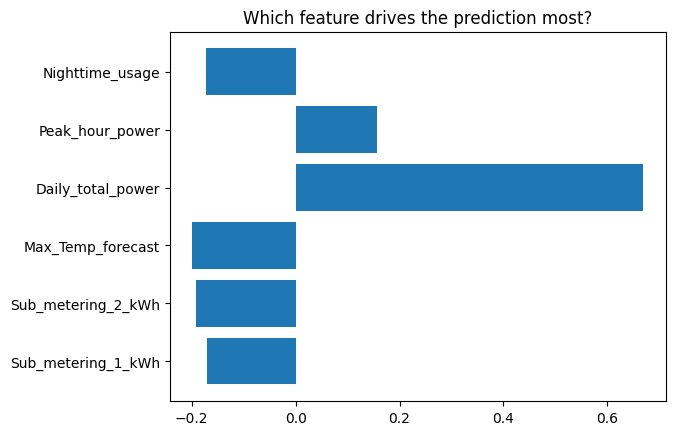

In [ ]:
plt.barh(X_train.columns, regressor.coef_)
plt.title("Which feature drives the prediction most?")
plt.show()

In [ ]:
#print(root_mean_squared_error(Y_test, Y_pred))
#print(mean_absolute_error(Y_test, Y_pred))

In [ ]:
df.columns

Index(['Sub_metering_1_kWh', 'Sub_metering_2_kWh', 'Sub_metering_3_kWh',
       'Daily_total_power', 'Peak_hour_power', 'Nighttime_usage',
       'Day_of_week', 'Month', 'Season', 'is_workDay', 'Consumption',
       'Min_Temp', 'Max_Temp', 'Mean_Humidity_Percentage',
       'Cloud_cover_Mean_Percentage', 'Next_Days_Consumption',
       'Prev_Days_Consumption', 'WeekAgo_Consumption', 'Min_Temp_forecast',
       'Max_Temp_forecast', 'Mean_Humidity_Percentage_forecast',
       'Cloud_cover_Mean_Percentage_forecast'],
      dtype='object')

In [ ]:
Xf = df.drop(['Next_Days_Consumption'], axis=1)
Yf = df['Next_Days_Consumption']

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=10)
# Δημιουργία μοντέλου με 100 δέντρα
rf_model = RandomForestRegressor(n_estimators=100, max_depth=None,
  min_samples_leaf=1,
  random_state=42,
  n_jobs=-1)

rf_model.fit(Xf, Yf)

# Cross-validation για να δούμε το νέο RMSE
rf_scores = cross_val_score(rf_model, Xf, Yf, cv = tscv, scoring='neg_mean_squared_error')
rf_rmse = np.sqrt(-rf_scores).mean()

print(f"Random Forest RMSE: {rf_rmse:.4f}")

Random Forest RMSE: 0.6790


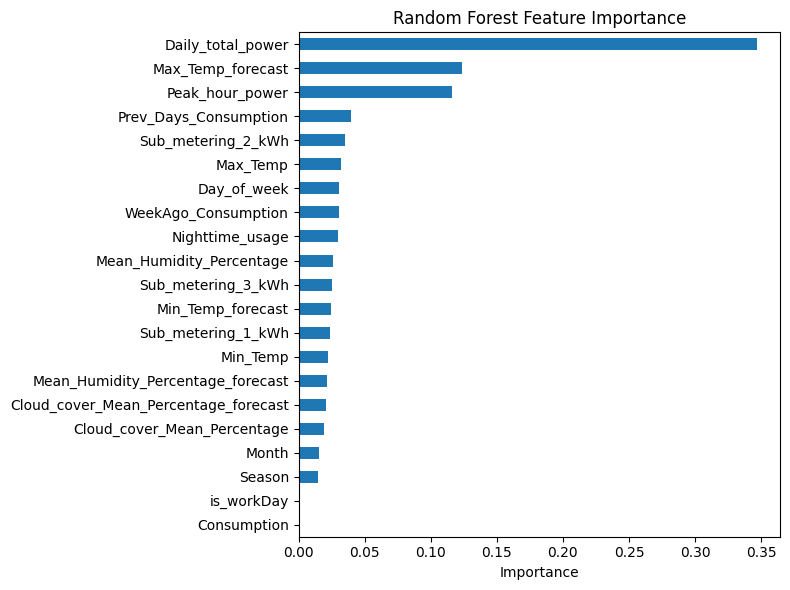

In [ ]:
importances = pd.Series(
    rf_model.feature_importances_,
    index=Xf.columns
).sort_values()

plt.figure(figsize=(8,6))
importances.plot(kind='barh')
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()


### **5.3 ΕΝΤΟΠΙΣΜΟΣ ΟΜΑΔΩΝ ΗΜΕΡΩΝ ΜΕ ΠΑΡΟΜΟΙΑ ΚΑΤΑΝΑΛΩΣΗ**

1.   List item
2.   List item



In [ ]:
from sklearn.cluster import KMeans

In [ ]:
df.columns

Index(['Sub_metering_1_kWh', 'Sub_metering_2_kWh', 'Sub_metering_3_kWh',
       'Daily_total_power', 'Peak_hour_power', 'Nighttime_usage',
       'Day_of_week', 'Month', 'Season', 'is_workDay', 'Consumption',
       'Min_Temp', 'Max_Temp', 'Mean_Humidity_Percentage',
       'Cloud_cover_Mean_Percentage', 'Next_Days_Consumption',
       'Prev_Days_Consumption', 'WeekAgo_Consumption', 'Min_Temp_forecast',
       'Max_Temp_forecast', 'Mean_Humidity_Percentage_forecast',
       'Cloud_cover_Mean_Percentage_forecast'],
      dtype='object')

### **5.3 Clustering**


In [ ]:
# Χρησιμοποιούμε χαρακτηριστικά που περιγράφουν τη συμπεριφορά της ημέρας
features_clustering = [
   'Daily_total_power',
#   'Peak_hour_power',
#   'Nighttime_usage',
   'is_workDay',
#   'Sub_metering_1_kWh',
#   'Sub_metering_2_kWh',
#   'Sub_metering_3_kWh',
#   'Day_of_week'
#   'Month',
#   'Season'
#    'Max_Temp_forecast'
]

X_cluster = df[features_clustering]


In [ ]:
# Θα δοκιμάσουμε k = 2 έως 6 και θα αξιολογήσουμε.
# Silhouette Score → όσο μεγαλύτερο τόσο καλύτερα
# Davies–Bouldin → όσο μικρότερο τόσο καλύτερα

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score

results = []

for k in range(2, 7):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_cluster)

    sil = silhouette_score(X_cluster, labels)
    db = davies_bouldin_score(X_cluster, labels)

    results.append((k, sil, db))

results


[(2, np.float64(0.426555902659707), np.float64(0.88506497328134)),
 (3, np.float64(0.40513186256262135), np.float64(0.8810407804583124)),
 (4, np.float64(0.4678776950200326), np.float64(0.7185783566811619)),
 (5, np.float64(0.4906081856655681), np.float64(0.7121723250551814)),
 (6, np.float64(0.5056192239063136), np.float64(0.7170931237247412))]

In [ ]:
# Επιλογή k=3 γιατί η εργασία ζητάει τουλάχιστον 3
kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_cluster)


In [ ]:
# Μέσοι όροι ανά συστάδα
cluster_summary = df.groupby('Cluster')[features_clustering].mean()
cluster_summary


,Daily_total_power,is_workDay
Cluster,,
0,-1.028156,0.213552
1,0.212168,0.228412
2,1.583525,0.631818


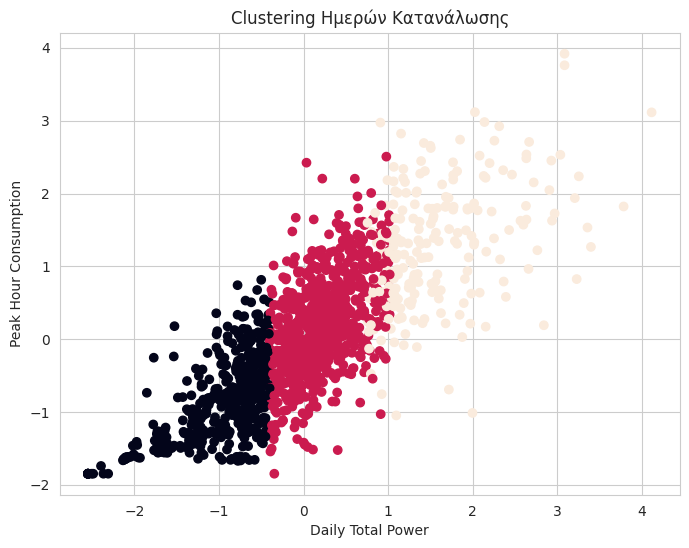

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(
    df['Daily_total_power'],
    df['Peak_hour_power'],
    c=df['Cluster']
)
plt.xlabel("Daily Total Power")
plt.ylabel("Peak Hour Consumption")
plt.title("Clustering Ημερών Κατανάλωσης")
plt.show()


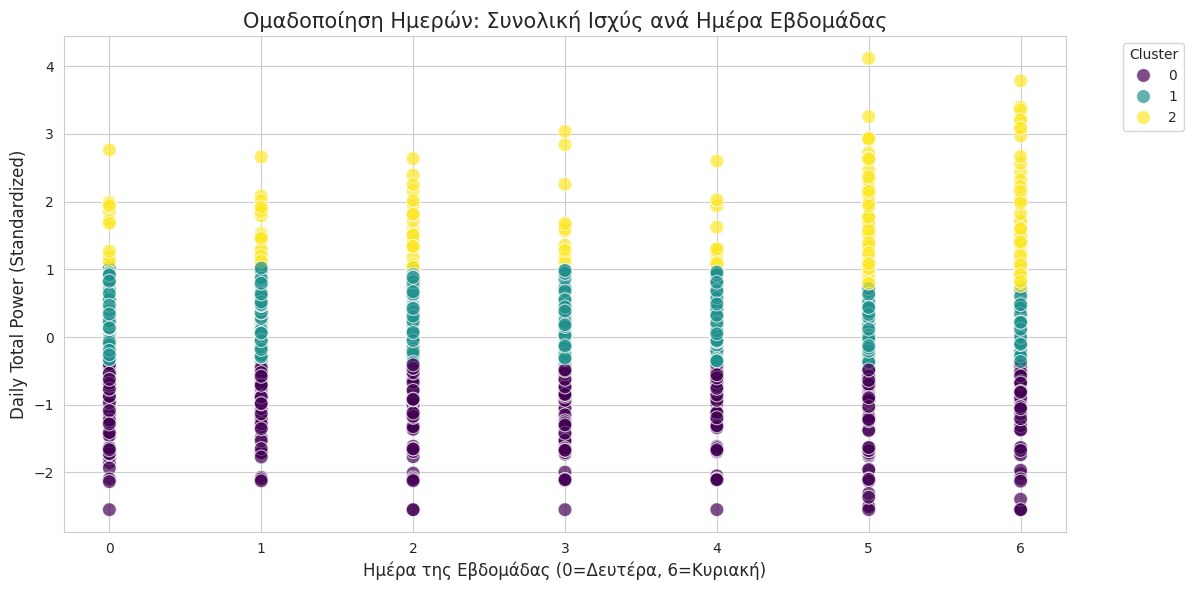

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Ορισμός του στυλ
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")

# Δημιουργία του Scatter Plot
# Χρησιμοποιούμε την ημέρα στον άξονα Χ και την ισχύ στον Υ
scatter = sns.scatterplot(
    data=df,
    x='Day_of_week',
    y='Daily_total_power',
    hue='Cluster',
    palette='viridis',
    s=100,
    alpha=0.7
)

# Ρυθμίσεις αξόνων και τίτλων
plt.title('Ομαδοποίηση Ημερών: Συνολική Ισχύς ανά Ημέρα Εβδομάδας', fontsize=15)
plt.xlabel('Ημέρα της Εβδομάδας (0=Δευτέρα, 6=Κυριακή)', fontsize=12)
plt.ylabel('Daily Total Power (Standardized)', fontsize=12)

# Βελτίωση του Legend
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

## **5.4 Κανόνες Συσχέτισης**

In [ ]:
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)


In [ ]:
import pandas as pd
from mlxtend.frequent_patterns import apriori, association_rules

# 1. Δημιουργία αντιγράφου για το binning
basket = pd.DataFrame(index=df.index)
basket

""
Datetime
2006-12-31
2007-01-01
2007-01-02
2007-01-03
2007-01-04
...
2010-11-20
2010-11-21
2010-11-22


In [ ]:
# 2. Binning για τα συνεχή χαρακτηριστικά (kWh και Forecasts)
# Χωρίζουμε σε Low (κάτω από το median) και High (πάνω από το median)
cols_to_bin = ['Daily_total_power', 'Max_Temp_forecast', 'Sub_metering_1_kWh',
               'Sub_metering_2_kWh', 'Sub_metering_3_kWh', 'Prev_Days_Consumption']

for col in cols_to_bin:
    median = df[col].median()
    basket[col + '_High'] = df[col] > median
basket

,Daily_total_power_High,Max_Temp_forecast_High,Sub_metering_1_kWh_High,Sub_metering_2_kWh_High,Sub_metering_3_kWh_High,Prev_Days_Consumption_High
Datetime,,,,,,
2006-12-31,True,False,False,False,False,True
2007-01-01,True,False,False,False,False,True
2007-01-02,False,False,False,False,False,True
2007-01-03,False,False,False,False,False,False
2007-01-04,True,False,False,True,True,False
...,...,...,...,...,...,...
2010-11-20,True,False,True,True,True,True
2010-11-21,False,False,False,False,False,True
2010-11-22,True,False,True,True,True,False


In [ ]:
# 3. Προσθήκη των ήδη κατηγορικών (ως Boolean)
basket['Weekend'] = df['is_workDay'] == 0
basket['High_Consumption_Flag'] = df['Consumption'] == 1 # Η στήλη 0/1 που είχες
basket

,Daily_total_power_High,Max_Temp_forecast_High,Sub_metering_1_kWh_High,Sub_metering_2_kWh_High,Sub_metering_3_kWh_High,Prev_Days_Consumption_High,Weekend,High_Consumption_Flag
Datetime,,,,,,,,
2006-12-31,True,False,False,False,False,True,False,True
2007-01-01,True,False,False,False,False,True,True,True
2007-01-02,False,False,False,False,False,True,True,False
2007-01-03,False,False,False,False,False,False,True,False
2007-01-04,True,False,False,True,True,False,True,True
...,...,...,...,...,...,...,...,...
2010-11-20,True,False,True,True,True,True,False,True
2010-11-21,False,False,False,False,False,True,False,False
2010-11-22,True,False,True,True,True,False,True,True


In [ ]:
# 4. Εκτέλεση Apriori
frequent_itemsets = apriori(basket, min_support=0.1, use_colnames=True)

frequent_itemsets

,support,itemsets
0,0.499649,(Daily_total_power_High)
1,0.496842,(Max_Temp_forecast_High)
2,0.498947,(Sub_metering_1_kWh_High)
3,0.499649,(Sub_metering_2_kWh_High)
4,0.499649,(Sub_metering_3_kWh_High)
...,...,...
119,0.183158,"(Weekend, High_Consumption_Flag, Prev_Days_Con..."
120,0.105263,"(High_Consumption_Flag, Sub_metering_1_kWh_Hig..."
121,0.103860,"(Weekend, High_Consumption_Flag, Sub_metering_..."
122,0.105263,"(Sub_metering_1_kWh_High, High_Consumption_Fla..."


In [ ]:
# 5. Παραγωγή κανόνων
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.2)

# Φιλτράρισμα για να δούμε τι "προκαλεί" την υψηλή συνολική κατανάλωση
high_cons_rules = rules[rules['consequents'].apply(lambda x: 'Daily_total_power_High' in str(x))]

print(high_cons_rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].sort_values(by='lift', ascending=False).head(10))

                                           antecedents  \
812                   (Weekend, High_Consumption_Flag)   
809  (Prev_Days_Consumption_High, Sub_metering_3_kW...   
380                   (Weekend, High_Consumption_Flag)   
207   (Sub_metering_2_kWh_High, High_Consumption_Flag)   
676  (Sub_metering_1_kWh_High, Weekend, High_Consum...   
379   (Sub_metering_3_kWh_High, High_Consumption_Flag)   
208   (Sub_metering_1_kWh_High, High_Consumption_Flag)   
555   (Sub_metering_1_kWh_High, High_Consumption_Flag)   
549  (Sub_metering_3_kWh_High, Sub_metering_2_kWh_H...   
802  (Prev_Days_Consumption_High, Weekend, High_Con...   

                                           consequents   support  confidence  \
812  (Prev_Days_Consumption_High, Daily_total_power...  0.183158    0.576159   
809                  (Daily_total_power_High, Weekend)  0.183158    0.670951   
380  (Daily_total_power_High, Sub_metering_3_kWh_High)  0.253333    0.796909   
207  (Daily_total_power_High, Sub_meterin

## **5.5 Πρόβλεψη Χρονοσειρών**



In [ ]:
prophet_df = df.reset_index()[['Datetime', 'Daily_total_power',
                               'Min_Temp_forecast', 'Max_Temp_forecast',
                               'Mean_Humidity_Percentage_forecast']]
prophet_df.columns = [
    'ds',
    'y',
    'min_temp',
    'max_temp',
    'humidity'
]

In [ ]:
split_date = prophet_df['ds'].quantile(0.8)

train = prophet_df[prophet_df['ds'] <= split_date]
test  = prophet_df[prophet_df['ds'] > split_date]


In [ ]:
from prophet import Prophet

model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False
)

model.add_regressor('min_temp')
model.add_regressor('max_temp')
model.add_regressor('humidity')

model.fit(train)


In [ ]:
future = model.make_future_dataframe(
    periods=len(test),
    freq='D'
)

future = future.merge(
    prophet_df[['ds', 'min_temp', 'max_temp', 'humidity']],
    on='ds',
    how='left'
)

forecast = model.predict(future)


In [ ]:
forecast_test = forecast[['ds', 'yhat']].tail(len(test))


In [ ]:
import pandas as pd

df_raw = pd.read_pickle('/content/drive/MyDrive/Data_Mining/Projects/df_denormanized.pkl')

In [ ]:
import numpy as np


mean_power = df_raw['Daily_total_power'].mean()
std_power = df_raw['Daily_total_power'].std()

y_true_denorm = test['y'].values * std_power + mean_power
y_pred_denorm = forecast_test['yhat'].values * std_power + mean_power

rmse_denorm = np.sqrt(mean_squared_error(y_true_denorm, y_pred_denorm))
mape_denorm = np.mean(np.abs((y_true_denorm - y_pred_denorm) / y_true_denorm)) * 100

print(f"Denormalized RMSE: {rmse_denorm:.2f}")
print(f"Denormalized MAPE: {mape_denorm:.2f}%")

Denormalized RMSE: 7.09
Denormalized MAPE: 3650.72%


In [ ]:
# Mean και std από το denormalized dataset
mean_power = df_raw['Daily_total_power'].mean()
std_power = df_raw['Daily_total_power'].std()

# Denormalize τις προβλέψεις και τα πραγματικά values
y_true_denorm = test['y'].values * std_power + mean_power
y_pred_denorm = forecast_test['yhat'].values * std_power + mean_power

In [ ]:
# Έλεγχος για τιμές κοντά στο 0
near_zero = np.abs(y_true_denorm) < 1
print(f"\nΑριθμός τιμών < 1: {near_zero.sum()} από {len(y_true_denorm)}")
if near_zero.any():
    print(f"Indices με προβληματικές τιμές: {np.where(near_zero)[0][:10]}")


Αριθμός τιμών < 1: 6 από 285
Indices με προβληματικές τιμές: [186 187 188 189 225 226]


In [ ]:
# Χρησιμοποίησε το 5% του mean ή 1, όποιο είναι μεγαλύτερο
threshold = max(1.0, y_true_denorm.mean() * 0.05)
print(f"Threshold: {threshold:.2f}")

mask = y_true_denorm > threshold

rmse_denorm = np.sqrt(mean_squared_error(y_true_denorm, y_pred_denorm))
mape_denorm = np.mean(np.abs((y_true_denorm[mask] - y_pred_denorm[mask]) / y_true_denorm[mask])) * 100

print(f"Denormalized RMSE: {rmse_denorm:.2f}")
print(f"MAPE (filtered): {mape_denorm:.2f}%")

Denormalized RMSE: 7.09
MAPE (filtered): 34.37%


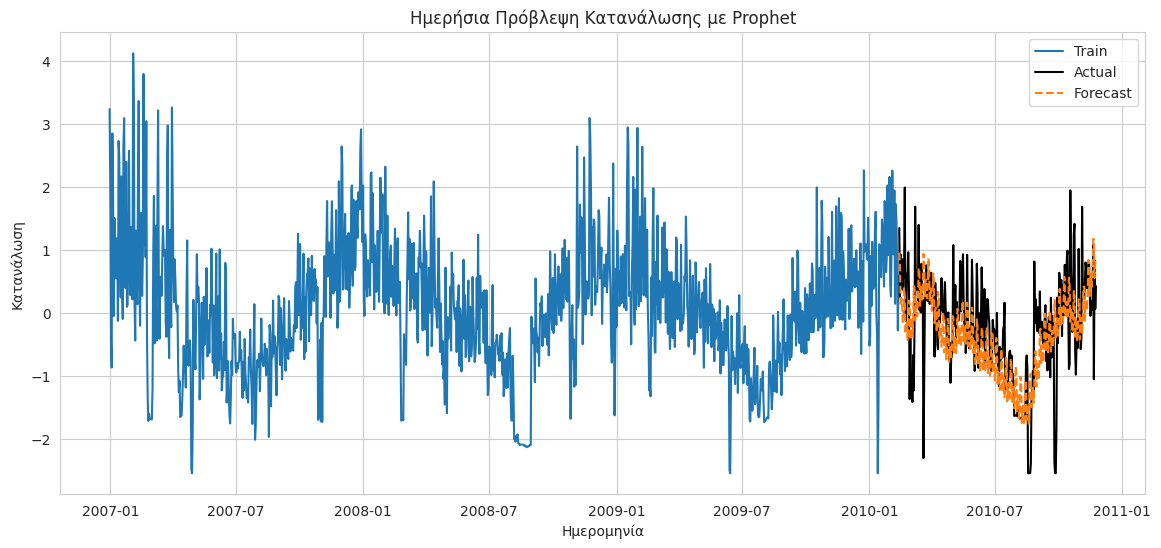

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))
plt.plot(train['ds'], train['y'], label='Train')
plt.plot(test['ds'], test['y'], label='Actual', color='black')
plt.plot(forecast_test['ds'], forecast_test['yhat'], label='Forecast', linestyle='--',)

plt.title("Ημερήσια Πρόβλεψη Κατανάλωσης με Prophet")
plt.xlabel("Ημερομηνία")
plt.ylabel("Κατανάλωση")
plt.legend()
plt.show()


In [ ]:
test['y'].describe()


,y
count,285.000000
mean,-0.243358
std,0.831792
min,-2.549324
25%,-0.699082
50%,-0.147916
75%,0.276739
max,1.983233
